# UNIVERSIDAD DE GUADALAJARA

## Centro Universitario de Ciencias Económico Administrativas (CUCEA)

### Estadística I

# Proyecto Final de Estadística

## Análisis Estadístico de Proyecciones de Población de la República Checa

**Alumna:** Frida Suárez De Luna  
**Profesor:** Rigoberto Silva Robles  
**Fecha:** Mayo 2026

# Índice

1. Introducción  
2. Medidas de Tendencia Central  
3. Medidas de Dispersión  
4. Introducción a Probabilidad  
5. Distribución de Probabilidad con VAD  
6. Distribución de Probabilidad con VAC  
7. Datos Agrupados  
8. Datos No Agrupados  
9. Rango  
10. Rango Intercuartílico  
11. Varianza  
12. Desviación Estándar  
13. Desviación Media  
14. Diagrama de Venn  
15. Conteo  
16. Combinación  
17. Permutación  
18. Probabilidad Condicional  
19. Teorema de Bayes  
20. Distribución Binomial  
21. Distribución Poisson  
22. Distribución Hipergeométrica  
23. Distribución Normal  
24. Distribución Normal Estándar  
25. Índice Paasche  
26. Índice Laspeyres  
27. Índice Fisher  

# Introducción

En este proyecto se realizó un análisis estadístico de datos poblacionales correspondientes a la República Checa.

Para el desarrollo del trabajo se utilizó Python como herramienta principal para procesar los datos, realizar cálculos estadísticos y generar gráficas que facilitan la interpretación de la información.

El objetivo fue aplicar los temas vistos en la materia de Estadística I, incluyendo medidas de tendencia central, medidas de dispersión, probabilidad, distribuciones de probabilidad e índices estadísticos.

Los datos fueron previamente limpiados y organizados para garantizar resultados correctos, y posteriormente se analizaron mediante distintos métodos matemáticos y gráficos.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving datos_limpios.xlsxSOLO.xlsx to datos_limpios.xlsxSOLO.xlsx


# Carga y limpieza de datos

En esta sección se cargó el archivo de Excel con los datos poblacionales de la República Checa.

Primero se identificó la fila donde comienza la tabla real. Después se eliminaron filas vacías, columnas innecesarias y se convirtieron los datos a valores numéricos.

Este proceso es importante porque permite trabajar con una base limpia y organizada para realizar correctamente los cálculos estadísticos.

**Interpretación:**

Después de limpiar los datos, la tabla quedó organizada por grupos de edad y por años.  
Esto permite utilizar la columna 2023 como base principal para calcular las medidas estadísticas del proyecto.

In [10]:
import pandas as pd

# nombre del archivo
archivo = "datos_limpios.xlsxSOLO.xlsx"

# leer hoja sin formato
df_raw = pd.read_excel(archivo, sheet_name="Table", header=None)

# detectar dónde empieza la tabla
fila_inicio = None

for i, row in df_raw.iterrows():
    if row.astype(str).str.contains("Age", case=False, na=False).any():
        fila_inicio = i
        break

print("Fila donde empieza la tabla:", fila_inicio)

# leer datos reales
df = pd.read_excel(archivo, sheet_name="Table", skiprows=fila_inicio)

# renombrar columna
df.rename(columns={df.columns[1]: "Edad"}, inplace=True)

# eliminar filas vacías
df = df[df["Edad"].notna()]

# eliminar filas basura
df = df[~df["Edad"].astype(str).str.contains("Sex", na=False)]

df = df.reset_index(drop=True)

# crear columnas de años
años = list(range(2023, 2023 + len(df.columns) - 3))
df.columns = ["col0", "Edad", "col2"] + [str(a) for a in años]

# eliminar columnas basura
df = df.drop(columns=["col0", "col2"])

# convertir a números
for col in df.columns[1:]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["2023"])

print("\nDATOS LIMPIOS:")
print(df.head())

Fila donde empieza la tabla: 7

DATOS LIMPIOS:
                  Edad       2023       2024       2025       2026       2027  \
0                Total  5642582.0  5616621.0  5591121.0  5565887.0  5541550.0   
1      4 years or less   276925.0   271896.0   265682.0   260892.0   257575.0   
2    From 5 to 9 years   296542.0   293260.0   290350.0   285252.0   278596.0   
3  From 10 to 14 years   296486.0   290988.0   288472.0   288501.0   289199.0   
4  From 15 to 19 years   295161.0   302179.0   304754.0   302408.0   296186.0   

        2028       2029       2030       2031  ...       2061       2062  \
0  5518633.0  5496571.0  5475129.0  5454403.0  ...  5307768.0  5298182.0   
1   252879.0   248629.0   245206.0   242644.0  ...   242273.0   241318.0   
2   274147.0   270544.0   265450.0   261567.0  ...   253852.0   252013.0   
3   289033.0   286986.0   285264.0   281258.0  ...   264003.0   262547.0   
4   289833.0   285292.0   283538.0   284326.0  ...   270115.0   270005.0   

        2

# Medidas de Tendencia Central

Las medidas de tendencia central permiten identificar valores representativos dentro de un conjunto de datos.

En este proyecto se calcularon:

- Media
- Mediana
- Moda

Estas medidas ayudan a entender el comportamiento general de la población.


MEDIDAS DE TENDENCIA CENTRAL

MEDIA: 1236097.1666666667
MEDIANA: 437400.0
MODA: 62698.0


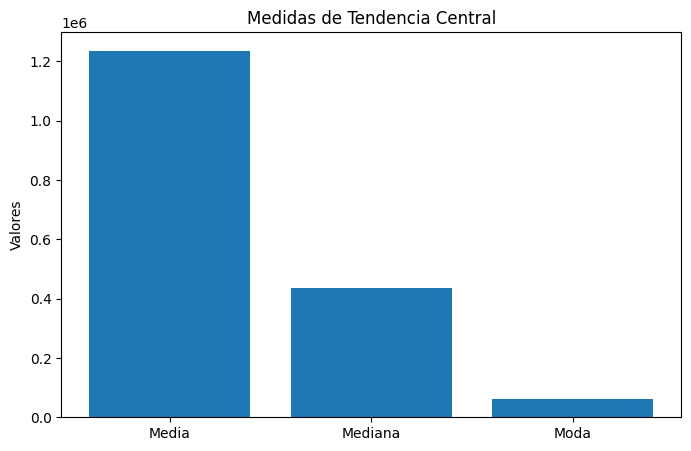

In [3]:
import matplotlib.pyplot as plt

print("\n==============================")
print("MEDIDAS DE TENDENCIA CENTRAL")
print("==============================")

# datos del año 2023
edades = df["2023"]

# -----------------------------
# MEDIA
# -----------------------------
media = edades.mean()
print("\nMEDIA:", media)

# -----------------------------
# MEDIANA
# -----------------------------
mediana = edades.median()
print("MEDIANA:", mediana)

# -----------------------------
# MODA
# -----------------------------
moda = edades.mode()[0]
print("MODA:", moda)

# -----------------------------
# GRÁFICA
# -----------------------------
plt.figure(figsize=(8,5))

nombres = ["Media", "Mediana", "Moda"]
valores = [media, mediana, moda]

plt.bar(nombres, valores)

plt.title("Medidas de Tendencia Central")
plt.ylabel("Valores")

plt.savefig("tendencia_central.png")
plt.show()

**Interpretación:**

La media fue aproximadamente 1,236,097, la mediana 437,400 y la moda 62,698.

La media es mayor que la mediana, lo que indica que existen valores altos que elevan el promedio.

La gráfica permite comparar visualmente estas tres medidas.

# Medidas de Dispersión

Las medidas de dispersión permiten conocer qué tan separados están los datos respecto a un valor central.

En este análisis se calcularon:

- Rango
- Rango intercuartílico
- Varianza
- Desviación estándar
- Desviación media

Además, se utilizaron gráficas como el histograma y el boxplot para visualizar la distribución de los datos.


MEDIDAS DE DISPERSIÓN

RANGO: 10970708.0
RANGO INTERCUARTÍLICO: 641764.5
VARIANZA: 3718297922790.282
DESVIACIÓN ESTÁNDAR: 1928288.8587528276
DESVIACIÓN MEDIA: 1251769.5416666667


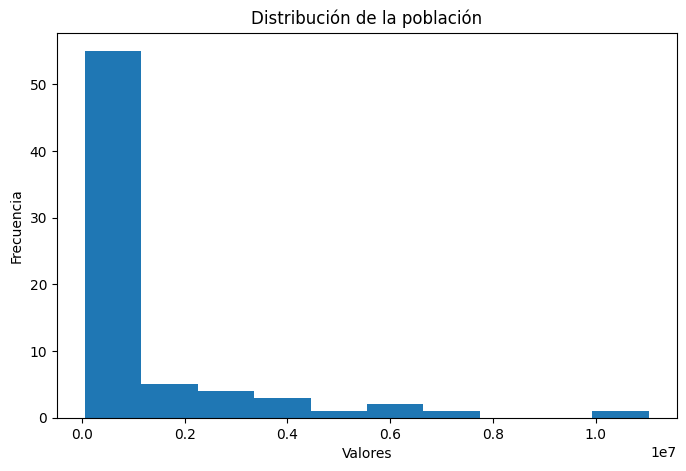

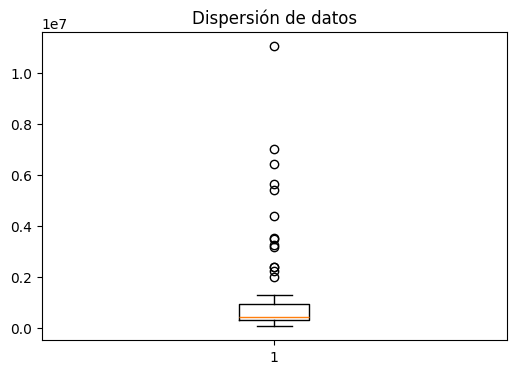

In [4]:
print("\n==============================")
print("MEDIDAS DE DISPERSIÓN")
print("==============================")

# -----------------------------
# RANGO
# -----------------------------
rango = edades.max() - edades.min()
print("\nRANGO:", rango)

# -----------------------------
# RANGO INTERCUARTÍLICO
# -----------------------------
Q1 = edades.quantile(0.25)
Q3 = edades.quantile(0.75)
RIC = Q3 - Q1

print("RANGO INTERCUARTÍLICO:", RIC)

# -----------------------------
# VARIANZA
# -----------------------------
varianza = edades.var()
print("VARIANZA:", varianza)

# -----------------------------
# DESVIACIÓN ESTÁNDAR
# -----------------------------
desv = edades.std()
print("DESVIACIÓN ESTÁNDAR:", desv)

# -----------------------------
# DESVIACIÓN MEDIA
# -----------------------------
desv_media = abs(edades - edades.mean()).mean()
print("DESVIACIÓN MEDIA:", desv_media)


# =============================
# GRÁFICA HISTOGRAMA
# =============================
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(edades, bins=10)

plt.title("Distribución de la población")
plt.xlabel("Valores")
plt.ylabel("Frecuencia")

plt.savefig("histograma.png")
plt.show()


# =============================
# GRÁFICA BOXPLOT
# =============================

plt.figure(figsize=(6,4))

plt.boxplot(edades)

plt.title("Dispersión de datos")

plt.savefig("boxplot.png")
plt.show()

**Interpretación:**

El rango obtenido muestra que existe una gran diferencia entre los valores mínimos y máximos.

La varianza y la desviación estándar son altas, lo que indica que los datos están muy dispersos.

El histograma permite observar la distribución de la población, mientras que el boxplot muestra la variabilidad y posibles valores extremos.

# Probabilidad

La probabilidad permite medir la posibilidad de que ocurra un evento.

En este proyecto se analizó la probabilidad de seleccionar personas pertenecientes a ciertos grupos de edad dentro de la población total.

Se calcularon:

- Probabilidad básica
- Probabilidad condicional
- Teorema de Bayes


PROBABILIDAD

PROBABILIDAD BÁSICA P(A): 0.04907770945996

P(B): 0.41664223931526384
P(A|B): 0.11779340841825688

TEOREMA DE BAYES: 0.11779340841825688


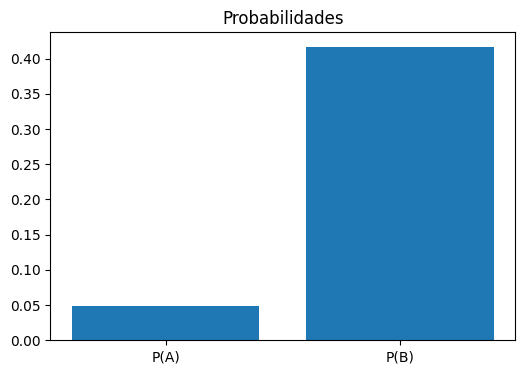

In [5]:
print("\n==============================")
print("PROBABILIDAD")
print("==============================")

# total población
total_2023 = df[df["Edad"] == "Total"]["2023"].values[0]

# menores de 4
menores_4 = df[df["Edad"] == "4 years or less"]["2023"].values[0]

# -----------------------------
# PROBABILIDAD BÁSICA
# -----------------------------
P_A = menores_4 / total_2023

print("\nPROBABILIDAD BÁSICA P(A):", P_A)

# -----------------------------
# PROBABILIDAD CONDICIONAL
# -----------------------------
menores_10 = df[df["Edad"].isin([
    "4 years or less",
    "From 5 to 9 years"
])]["2023"].sum()

P_B = menores_10 / total_2023
P_A_dado_B = P_A / P_B

print("\nP(B):", P_B)
print("P(A|B):", P_A_dado_B)

# -----------------------------
# TEOREMA DE BAYES
# -----------------------------
print("\nTEOREMA DE BAYES:", P_A_dado_B)


# =============================
# GRÁFICA DE PROBABILIDAD
# =============================

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

nombres = ["P(A)", "P(B)"]
valores = [P_A, P_B]

plt.bar(nombres, valores)

plt.title("Probabilidades")

plt.savefig("probabilidades.png")
plt.show()

**Interpretación:**

La probabilidad básica indica la proporción de personas menores de 4 años dentro de la población total.

La probabilidad condicional permite analizar la relación entre los grupos de edad, en este caso entre menores de 4 años y menores de 10 años.

El teorema de Bayes ayuda a interpretar estas probabilidades considerando información previa, mostrando que aproximadamente el 11.77% del grupo de menores de 10 años corresponde a personas de 4 años o menos.

# Distribuciones de Probabilidad

Las distribuciones de probabilidad permiten modelar el comportamiento de los datos en distintos escenarios.

En este proyecto se aplicaron:

- Distribución binomial
- Distribución Poisson
- Distribución hipergeométrica
- Distribución normal

Cada una de estas distribuciones ayuda a analizar diferentes tipos de eventos dentro de la población.


DISTRIBUCIONES

BINOMIAL: 0.025566756438429688
POISSON: 0.046727237547113554
HIPERGEOMÉTRICA: 0.0572718809353194


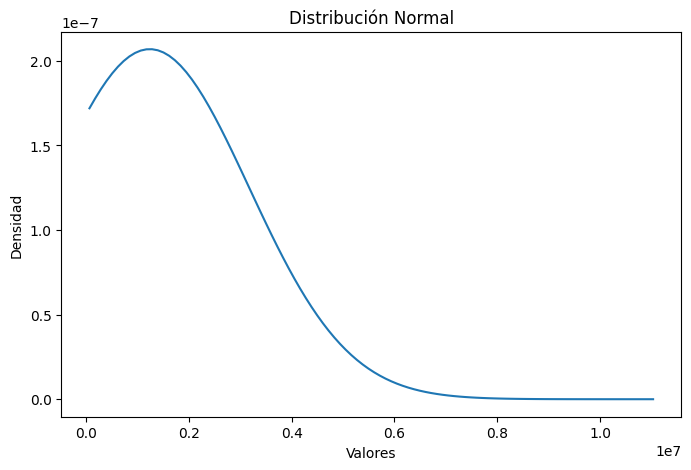


Z: -0.38173594341190004


In [6]:
import math
from scipy.stats import hypergeom, norm
import numpy as np
import matplotlib.pyplot as plt

print("\n==============================")
print("DISTRIBUCIONES")
print("==============================")

# -----------------------------
# BINOMIAL
# -----------------------------
p = P_B
n = 1000
k = int(n * p)

binomial = math.comb(n, k) * (p ** k) * ((1 - p) ** (n - k))

print("\nBINOMIAL:", binomial)

# -----------------------------
# POISSON
# -----------------------------
lambda_ = P_A
k_poisson = 1

poisson = math.exp(-lambda_) * (lambda_ ** k_poisson) / math.factorial(k_poisson)

print("POISSON:", poisson)

# -----------------------------
# HIPERGEOMÉTRICA
# -----------------------------
N = int(total_2023)
K = int(menores_4)
n_hiper = 1000
x = 50

hiper = hypergeom.pmf(x, N, K, n_hiper)

print("HIPERGEOMÉTRICA:", hiper)

# -----------------------------
# DISTRIBUCIÓN NORMAL
# -----------------------------
mu = edades.mean()
sigma = edades.std()

x_vals = np.linspace(edades.min(), edades.max(), 100)
y_vals = norm.pdf(x_vals, mu, sigma)

plt.figure(figsize=(8,5))
plt.plot(x_vals, y_vals)

plt.title("Distribución Normal")
plt.xlabel("Valores")
plt.ylabel("Densidad")

plt.savefig("distribucion_normal.png")
plt.show()

# -----------------------------
# NORMAL ESTÁNDAR (Z)
# -----------------------------
x_z = 500000
z = (x_z - mu) / sigma

print("\nZ:", z)

**Interpretación:**

La distribución binomial permite calcular la probabilidad de obtener un número específico de casos dentro de una muestra.

La distribución Poisson se utiliza para modelar eventos poco frecuentes.

La distribución hipergeométrica se aplica cuando se seleccionan elementos sin reemplazo, como en el caso de muestras de población.

La distribución normal muestra cómo se comportan los datos alrededor de la media, permitiendo observar la forma general de la distribución.

El valor Z indica qué tan lejos se encuentra un dato respecto a la media, en este caso el valor analizado se encuentra ligeramente por debajo del promedio.

# Índices Estadísticos

Los índices estadísticos permiten comparar el comportamiento de los datos en distintos periodos de tiempo.

En este proyecto se calcularon:

- Índice Laspeyres
- Índice Paasche
- Índice Fisher

Estos índices ayudan a analizar cambios en la población entre diferentes años.


ÍNDICES ESTADÍSTICOS
Índice Laspeyres: 99.8345988533229
Índice Paasche: 99.83946900654631
Índice Fisher: 99.83703390023823


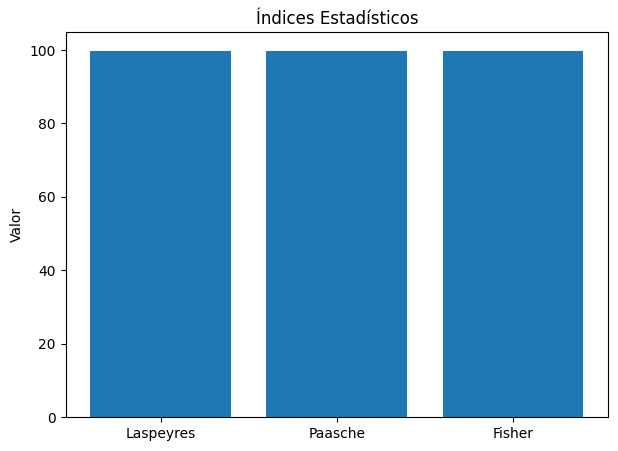

In [7]:
print("\n==============================")
print("ÍNDICES ESTADÍSTICOS")
print("==============================")

base = df["2023"]
actual = df["2024"]

# Índice Laspeyres
laspeyres = ((actual * base).sum() / (base * base).sum()) * 100

# Índice Paasche
paasche = ((actual * actual).sum() / (base * actual).sum()) * 100

# Índice Fisher
fisher = math.sqrt(laspeyres * paasche)

print("Índice Laspeyres:", laspeyres)
print("Índice Paasche:", paasche)
print("Índice Fisher:", fisher)

# Gráfica
plt.figure(figsize=(7,5))

plt.bar(
    ["Laspeyres", "Paasche", "Fisher"],
    [laspeyres, paasche, fisher]
)

plt.title("Índices Estadísticos")
plt.ylabel("Valor")

plt.savefig("indices.png")
plt.show()

# Conclusión

En este proyecto se aplicaron los principales conceptos de la materia de Estadística I utilizando datos reales de población de la República Checa.

Se utilizaron herramientas de Python para limpiar los datos, calcular medidas estadísticas y generar gráficas que permitieron interpretar los resultados de manera visual.

Las medidas de tendencia central mostraron que existen valores altos que influyen en el promedio, mientras que las medidas de dispersión evidenciaron una gran variabilidad en los datos.

Las probabilidades y distribuciones permitieron analizar diferentes escenarios dentro de la población, y los índices estadísticos ayudaron a comparar el comportamiento de los datos entre distintos años.

En general, el proyecto permitió comprender cómo aplicar la estadística en situaciones reales, facilitando el análisis y la toma de decisiones basadas en datos.